# Word Cloud using CSV (En)

Data: Movie Reviews (`./data/movie_reviews_en.csv`)

### 1. Load Data

In [2]:
import pandas as pd

df = pd.read_csv('./data/movie_reviews_en.csv', sep=',')
df.head()

,text,label
0,If you havent seen this movie than you need to...,1
1,but Cinderella gets my vote not only for the w...,0
2,This movie is pretty cheesy but I do give it c...,1
3,I have not seen a Van Damme flick for a while ...,1
4,This is a sleeper It defines Nicholas Cage The...,1


In [3]:
df.shape

(40000, 2)

In [4]:
df['label'].value_counts() #.to_frame()

label
0    20049
1    19951
Name: count, dtype: int64

### 2. Text Preprocessing

In [5]:
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud
from matplotlib import pyplot as plt

def get_preprocessed_corpus(text, custom_stopwords=None):
    text = text.lower()
    words = word_tokenize(text)
    # tagged = pos_tag(words)
    # words = [w for w, pos in tagged if pos[0] == 'N'] # keep only nouns

    stop_words_list = stopwords.words('english')
    if custom_stopwords is not None:
        stop_words_list += custom_stopwords  # Add any custom stopwords if needed
    words_filtered = [w for w in words if not w in stop_words_list]
    return ' '.join(words_filtered)


def draw_wordcloud(text, title=None):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [6]:
custom_stopwords = ['movie', 'movies', 'film', 'films', 'one', 'character', 'characters', 'make', 'made', 'story', 'see', 'seen', 'saw', 'seem', 'show', 'time', ]
df['processed_review'] = df['text'].apply(lambda x: get_preprocessed_corpus(x, custom_stopwords=custom_stopwords))

### 3. Draw Wordclouds

#### 3-1. All reviews

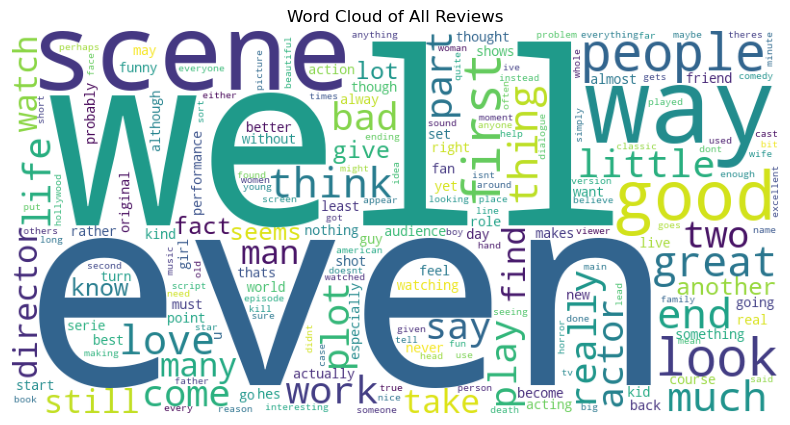

In [7]:
text_all = ' '.join(df['processed_review'])

draw_wordcloud(text_all, title='Word Cloud of All Reviews')

#### 3-2. Positive/Negative Reviews


In [8]:
pos_reviews = df.loc[df['label']==1, 'processed_review']
neg_reviews = df.loc[df['label']==0, 'processed_review']

print('Number of positive reviews:', len(pos_reviews))
print('Number of negative reviews:', len(neg_reviews))

Number of positive reviews: 19951
Number of negative reviews: 20049


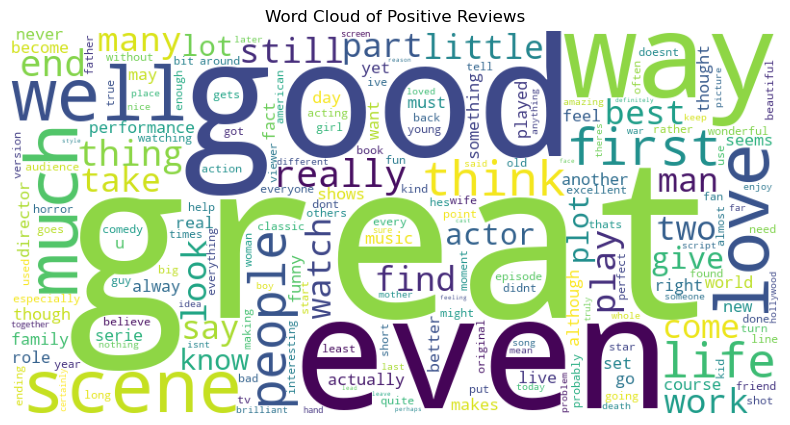

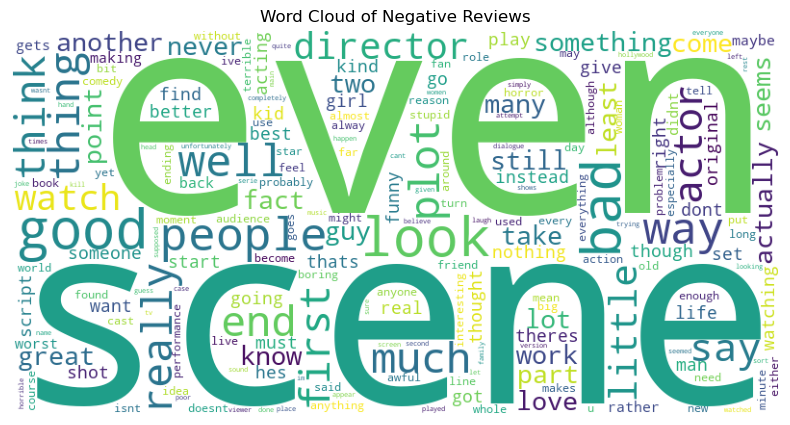

In [9]:
text_pos = ' '.join(pos_reviews)
draw_wordcloud(text_pos, title='Word Cloud of Positive Reviews')

text_neg = ' '.join(neg_reviews)
draw_wordcloud(text_neg, title='Word Cloud of Negative Reviews')

#### Drill-down: Let's try to understand the context of keywords!

In [ ]:
# Q. Find and display some negative reviews that contain the word "good"
df.loc[(df['label']==0) & (df['processed_review'].str.contains('good')), ['text', 'processed_review']]

,text,processed_review
1,but Cinderella gets my vote not only for the w...,cinderella gets vote worst disneys princess wo...
5,This movie has no heart and no soul its an att...,heart soul attempt whomp cult leavings better ...
14,John Scott John Wayne and partner Kansas Charl...,john scott john wayne partner kansas charlie e...
18,This is the kind of movie that BEGS to be show...,kind begs shown tv 3 4 morning doubt filmmaker...
20,OK I for one thought the trailer was quite goo...,ok thought trailer quite good hopeful plus cas...
...,...,...
39986,i was given the book version of Kazaam for my ...,given book version kazaam 8th birthday people ...
39990,This movie is silly and very short of being a ...,silly short funny unhappy easterners pleased w...
39991,I have a 5 minute rule sometimes Ill leave lew...,5 minute rule sometimes ill leave leway 10 goo...
39994,This movie is one of the worst movie i have ev...,worst ever life waste watched completely took ...


In [ ]:
# get the text of the review having index 1
df.loc[1].text

'but Cinderella gets my vote not only for the worst of Disneys princess movies but for the worst movie the company made during Walts lifetime The music is genuinely pretty and the story deserves to be called classic What fails in this movie are the characters particularly the title character who could only be called the heroine in the loosest sense of the term After a brief prologue the audience is introduced to Cinderella She is waking up in the morning and singing A Dream is A wish Your Heart Makes This establishes her as an idealist and thus deserving of our sympathy Unfortunately the script gives us no clue as to what she is dreaming about Freedom from her servant role The respect of her stepfamily Someone to talk to besides mice and birds In one song cut from the movie but presented in the special features section of the latest DVD Cinderella relates her wish that there could be many of her so she could do her work more efficiently You go girlfriend In short Cinderella is a very b

In [17]:
df.loc[1].processed_review

'cinderella gets vote worst disneys princess worst company walts lifetime music genuinely pretty deserves called classic fails particularly title could called heroine loosest sense term brief prologue audience introduced cinderella waking morning singing dream wish heart makes establishes idealist thus deserving sympathy unfortunately script gives us clue dreaming freedom servant role respect stepfamily someone talk besides mice birds song cut presented special features section latest dvd cinderella relates wish could many could work efficiently go girlfriend short cinderella bland passively accepts stepfamilys abuse escaping unspoken dreams relief asserts reminding stepmother still member family given permission go ball completes housework finds something wear token gesture clearly absurd everyone except course cinderella anyone belle jasmine doormat cinderella dull male counterpart nothing short lifeless prince cinderella gets dialog almost screen given indication good man respects c

In [20]:
# Q. Find and display some reviews that contain the word "even"
df.loc[(df['label']==0) & (df['processed_review'].str.contains('even')), ['text', 'processed_review']]

,text,processed_review
1,but Cinderella gets my vote not only for the w...,cinderella gets vote worst disneys princess wo...
8,yeah cheap shot i know but this movie is a gre...,yeah cheap shot know great example collection ...
21,This movie was by far the worst movie that I h...,far worst ever entire life im even kidding poo...
22,Foolish hikers go camping in the Utah mountain...,foolish hikers go camping utah mountains run m...
23,Insane really Even if you havent seen the orig...,insane really even havent original george cuko...
...,...,...
39986,i was given the book version of Kazaam for my ...,given book version kazaam 8th birthday people ...
39988,I went to see this film last night at the Nati...,went last night national theatre london birthd...
39991,I have a 5 minute rule sometimes Ill leave lew...,5 minute rule sometimes ill leave leway 10 goo...
39998,And a selfadmitted one to boot At one point th...,selfadmitted boot point doctors assistant refe...
